In [5]:
import pandas as pd
# Yapay zeka dünyasının en meşhur metin dönüştürücüsünü çağırıyoruz
from sklearn.feature_extraction.text import TfidfVectorizer

# Verimizi tekrar okuyoruz
df = pd.read_csv("data/product_info.csv")

# Sadece ihtiyacımız olan sütunları alıp veriyi hafifletiyoruz
df_nlp = df[['ingredients', 'primary_category']].dropna()

# Bakalım elimizde kaç temiz satır kaldı
print("Temizlenen veri boyutu:", df_nlp.shape)

Temizlenen veri boyutu: (7549, 2)


In [7]:
# En sık geçen 2000 kozmetik içeriğini takibe alıyoruz
vectorizer = TfidfVectorizer(max_features=2000, stop_words='english')

# Bilgisayar kelimeleri öğreniyor ve sayısal matrise (X) dönüştürüyor
X = vectorizer.fit_transform(df_nlp['ingredients'])

# Hedef kategorilerimizi de (Y) değişkenine atıyoruz
y = df_nlp['primary_category']

print("Kelimeler başarıyla matematiksel matrise dönüştürüldü!")
print("Matris boyutu (Ürün Sayısı x Kelime Sayısı):", X.shape)

Kelimeler başarıyla matematiksel matrise dönüştürüldü!
Matris boyutu (Ürün Sayısı x Kelime Sayısı): (7549, 2000)


In [10]:
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score

# Veriyi %80 Eğitim, %20 Sınav (Test) olarak bölüyoruz
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Eğitim seti boyutu:", X_train.shape[0])
print("Test (Sınav) seti boyutu:", X_test.shape[0])

Eğitim seti boyutu: 6039
Test (Sınav) seti boyutu: 1510


In [11]:
# Naive Bayes modelimizi oluşturuyoruz
model = MultinomialNB()

# Yapay zeka şu an ders çalışıyor (Eğitim setiyle modeli besliyoruz)
model.fit(X_train, y_train)

# Şimdi yapay zekayı hayatında hiç görmediği %20'lik test setiyle sınava sokuyoruz
y_pred = model.predict(X_test)

# Sınavdan kaç aldığını (Başarı oranını) hesaplıyoruz
basari_orani = accuracy_score(y_test, y_pred)

print(f"Yapay Zekanın Sınav Başarı Oranı (Accuracy): %{basari_orani * 100:.2f}")

Yapay Zekanın Sınav Başarı Oranı (Accuracy): %81.85


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.3 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.3 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.3 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.3 MB ? eta -:--:--
   - -----------------------------

c:\Users\milkl\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\milkl\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\milkl\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

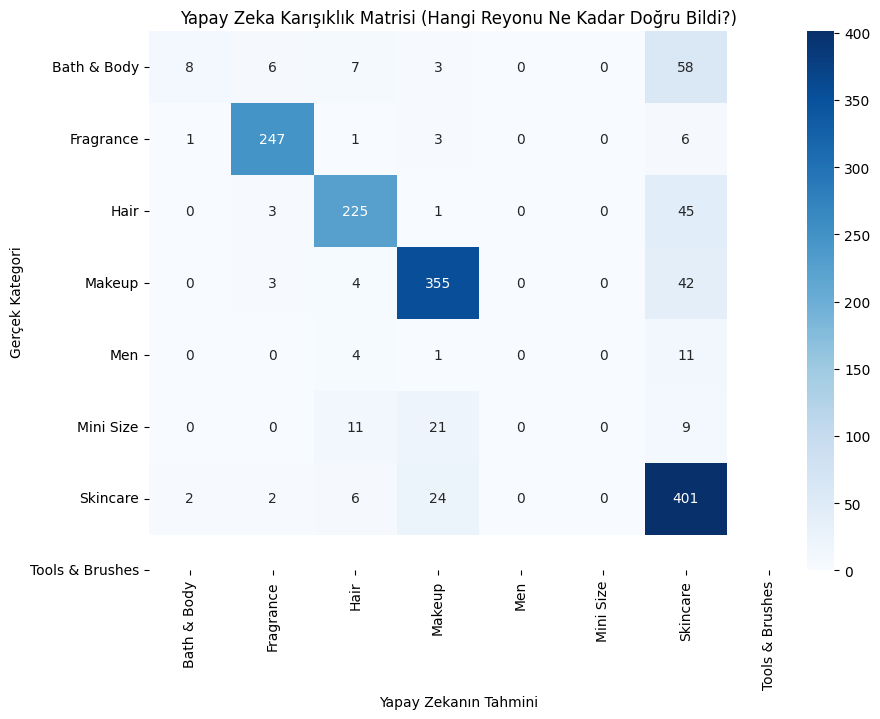

In [12]:
# Grafik çizdirmek için gerekli kütüphaneleri yüklüyor ve çağırıyoruz
!pip install matplotlib seaborn

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# 1. Detaylı Başarı Raporu (Hangi kategoride ne kadar iyi?)
print("DETAYLI BAŞARI RAPORU:\n")
print(classification_report(y_test, y_pred))

# 2. Karışıklık Matrisi (Confusion Matrix) Grafiği
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=model.classes_, yticklabels=model.classes_)
plt.title('Yapay Zeka Karışıklık Matrisi (Hangi Reyonu Ne Kadar Doğru Bildi?)')
plt.ylabel('Gerçek Kategori')
plt.xlabel('Yapay Zekanın Tahmini')
plt.show()

In [13]:
# Buraya istediğin içerikleri virgülle ayırarak yazabilirsin (Örn: Nemlendirici içerikleri)
ornek_icerik = ["Aqua, Glycerin, Niacinamide, Hyaluronic Acid, Centella Asiatica, Phenoxyethanol"]

# Yazdığımız metni yapay zekanın anlayacağı sayısal türe çeviriyoruz
ornek_vektor = vectorizer.transform(ornek_icerik)

# Yapay zekaya tahmin ettiriyoruz
canli_tahmin = model.predict(ornek_vektor)

print("-" * 50)
print(f"Girdiğin İçerikler: {ornek_icerik[0][:50]}...")
print(f"🔮 YAPAY ZEKANIN TAHMİNİ: --> {canli_tahmin[0].upper()} <--")
print("-" * 50)

--------------------------------------------------
Girdiğin İçerikler: Aqua, Glycerin, Niacinamide, Hyaluronic Acid, Cent...
🔮 YAPAY ZEKANIN TAHMİNİ: --> SKINCARE <--
--------------------------------------------------


In [14]:
import joblib

# Eğittiğimiz modeli ve kelime dönüştürücümüzü 'data' klasörüne kaydediyoruz
joblib.dump(model, 'data/kozmetik_nlp_modeli.pkl')
joblib.dump(vectorizer, 'data/kelime_vectorizer.pkl')

print("💾 Model ve Kelime Dönüştürücü başarıyla 'data' klasörüne kaydedildi!")

💾 Model ve Kelime Dönüştürücü başarıyla 'data' klasörüne kaydedildi!
